In [23]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
from matplotlib.lines import Line2D
import sys

sys.path.append("../../Modeling/fitting")
from optimization_utils import make_boundary, get_wmse

In [24]:
try:
    plt.rcParams["font.family"] = "Times New Roman"
except:
    from matplotlib import font_manager

    font_manager.fontManager.addfont("/home1/beigejin/Times.ttc")
    plt.rc("font", family="serif", serif=["Times"])
    plt.rcParams["mathtext.fontset"] = "custom"
    plt.rcParams["mathtext.rm"] = "Times"
plt.rcParams["font.size"] = 16
SAVEFIG = False
SAVERES = False

## Load Stimuli and Semantic Matrix

In [25]:
with open("simu2b_data/simu2b_design.pkl", "rb") as inp:
    df_study = pickle.load(inp)
    df_test = pickle.load(inp)
# df_study = df_study.query("session < 20")  # for testing
# df_test = df_test.query("session < 20")

In [26]:
df_study

,session,subj,list,trial,word1,word2,itemno1,itemno2
0,0,101,0,-1,formal,positive,422,759
1,0,101,0,0,skin,careful,930,158
2,0,101,0,1,upon,miss,1086,643
3,0,101,0,2,single,tradition,923,1059
4,0,101,0,3,prove,airport,793,35
...,...,...,...,...,...,...,...,...
53275,110,1150,7,54,forget,pocket,419,752
53276,110,1150,7,55,patient,plastic,723,742
53277,110,1150,7,56,justice,lord,544,593
53278,110,1150,7,57,society,caught,940,165


In [27]:
df_test

,session,subj,list,trial,word1,word2,itemno1,itemno2,type,lag,forward
0,0,101,0,-1,waste,degree,1112,269,rearranged,2,0
1,0,101,0,0,needed,able,673,2,rearranged,1,1
2,0,101,0,1,single,clean,923,193,rearranged,3,1
3,0,101,0,2,train,useful,1061,1089,rearranged,2,1
4,0,101,0,3,knees,various,552,1095,rearranged,5,1
...,...,...,...,...,...,...,...,...,...,...,...
53275,110,1150,7,54,opposite,period,703,729,intact,-1,0
53276,110,1150,7,55,card,limited,155,582,rearranged,2,1
53277,110,1150,7,56,soft,measure,941,620,rearranged,3,0
53278,110,1150,7,57,dark,fall,256,373,intact,-1,0


In [28]:
sem_mat = np.load("simu2b_data/simu2b_smat.npy")

## Run CMR-IA

In [29]:
# read pso results
_, _, what_to_fit = make_boundary(sim_name="2b")
optim_params = np.loadtxt("simu2b_data/2b_250616_200-200.txt")

# get params
params = cmr.make_default_params()
for pname, pvalue in zip(what_to_fit, optim_params):
    params[pname] = pvalue
params.update(use_new_context=True, use_flexible_thresh=True)
# beta_enc 0.4 can decrease, gamma_fc 0.4 can decrease
# params.update(beta_rec_post=0, beta_distract=0, s_fc=0)
# params.update(beta_enc=0.4)
params

{'beta_enc': 0.165159,
 'beta_rec': 0.5,
 'beta_cue': 0.504416,
 'beta_rec_post': 0.594594,
 'beta_distract': 0.452162,
 'phi_s': 2,
 'phi_d': 0.5,
 's_cf': 0,
 's_fc': 0.000933,
 'kappa': 0.5,
 'eta': 0.5,
 'omega': 5,
 'alpha': 1,
 'lamb': 0.5,
 'c_thresh': 0.5,
 'c_thresh_itm': 0.5,
 'c_thresh_assoc': 1.038428,
 'd_assoc': 1,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 50,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'use_new_context': True,
 'psi_s': 0,
 'psi_c': 1,
 'c_s': 0,
 'thresh_sigma': 0,
 'ban_recall': None,
 'var_enc': 1,
 'bad_enc_ratio': 1,
 'a': 2800,
 'b': 20,
 'gamma_fc': 0.046091,
 'gamma_cf': 0.5,
 'thresh_rate': 6.279106,
 'use_flexible_thresh': True}

In [30]:
for key in what_to_fit:
    print(f"{key}: {params[key]:.3f}")

beta_enc: 0.165
beta_cue: 0.504
beta_distract: 0.452
beta_rec_post: 0.595
s_fc: 0.001
gamma_fc: 0.046
c_thresh_assoc: 1.038
thresh_rate: 6.279


In [31]:
# out_dir = "/home1/beigejin/CMR-IA/Modeling/fitting/past_fits/2b_250519_200-100/outfiles"

# iter = 45
# min_err = np.inf
# for p in range(200):
#     path = f"{out_dir}/{iter}data{p}.pkl"
#     with open(path, "rb") as inp:
#         data = pickle.load(inp)
#     try:
#         err = data["err"]
#         b = data["params"]
#         if err < min_err:
#             min_err = err
#             best_p = p
#             best_b = b
#     except:
#         err = np.nan
#         b = np.nan

# best_p, best_b, min_err

# # define parameters
# params = cmr.make_default_params()
# params.update(use_new_context=True, use_flexible_thresh=True)

# # load pso results
# _, _, what_to_fit = make_boundary(sim_name="2b")
# # optim_params = np.loadtxt("simu8_data/8_250309_200-200.txt")
# optim_params = best_b
# for pname, pvalue in zip(what_to_fit, optim_params):
#     params[pname] = pvalue
# params.update(beta_enc=0.12, gamma_fc=0.08)
# params

In [32]:
# # define parameters
# params = cmr.make_default_params()
# params.update(
#     beta_enc=0.5,
#     beta_cue=0.5,
#     beta_distract=0.9,
#     beta_rec_post=0.9,
#     gamma_fc=0.5,
#     s_fc=0.1,
#     c_thresh_assoc=1,
#     use_new_context=True,
#     use_flexible_thresh=True,
# )
# params

In [33]:
if SAVERES:
    # run the model
    df_simu = cmr.run_norm_recog_multi_sess(params, df_study, df_test, sem_mat, mode="Osth")

    # merge to get more info
    df_simu = df_simu.merge(df_test, on=["session", "list", "itemno1", "itemno2"])

    # save
    df_simu.to_pickle("simu2b_data/simu2b_result.pkl")
else:
    # load results
    df_simu = pd.read_pickle("simu2b_data/simu2b_result.pkl")
df_simu

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subj,trial,word1,word2,type,lag,forward
0,0,0,1112,269,0,0,0.054789,0.090473,0.491080,101,-1,waste,degree,rearranged,2,0
1,0,0,673,2,1,0,0.058925,0.056958,0.500492,101,0,needed,able,rearranged,1,1
2,0,0,923,193,0,0,0.034671,0.061181,0.493373,101,1,single,clean,rearranged,3,1
3,0,0,1061,1089,1,0,0.053196,0.036051,0.504286,101,2,train,useful,rearranged,2,1
4,0,0,552,1095,0,0,0.041780,0.055205,0.496644,101,3,knees,various,rearranged,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53275,110,7,703,729,1,0,0.027001,0.023352,0.500912,1150,54,opposite,period,intact,-1,0
53276,110,7,155,582,0,0,0.023700,0.028029,0.498918,1150,55,card,limited,rearranged,2,1
53277,110,7,941,620,1,0,0.025179,0.024617,0.500141,1150,56,soft,measure,rearranged,3,0
53278,110,7,256,373,1,0,0.029409,0.026144,0.500816,1150,57,dark,fall,intact,-1,0


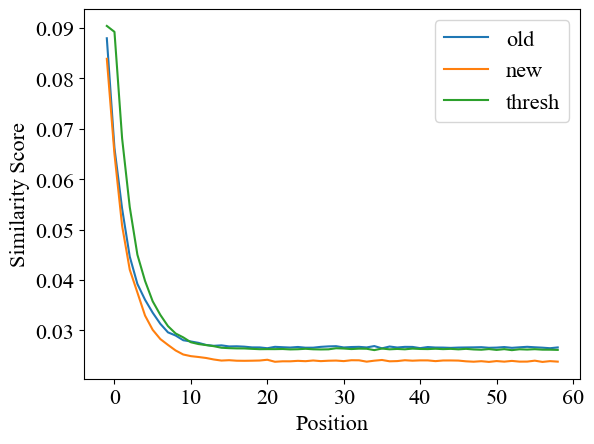

In [34]:
old_csim_pos = df_simu.query("type == 'intact'").groupby("trial").csim.mean()
old_pos = np.unique(df_simu.query("type == 'intact'").trial.to_numpy())
new_csim_pos = df_simu.query("type == 'rearranged'").groupby("trial").csim.mean()
new_pos = np.unique(df_simu.query("type == 'rearranged'").trial.to_numpy())
cthresh_pos = df_simu.groupby("trial").thresh.mean()
pos = np.unique(df_simu.trial.to_numpy())

plt.plot(old_pos, old_csim_pos, label="old")
plt.plot(new_pos, new_csim_pos, label="new")
plt.plot(pos, cthresh_pos, label="thresh")
plt.xlabel("Position")
plt.ylabel("Similarity Score")
plt.legend()
# plt.ylim(0.8, 0.9)
plt.show()

## Analysis

In [35]:
df_simu["old"] = df_simu.apply(lambda x: 1 if x["type"] == "intact" else 0, axis=1)
df_simu["correct"] = df_simu["s_resp"] == df_simu["old"]
df_simu

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subj,trial,word1,word2,type,lag,forward,old,correct
0,0,0,1112,269,0,0,0.054789,0.090473,0.491080,101,-1,waste,degree,rearranged,2,0,0,True
1,0,0,673,2,1,0,0.058925,0.056958,0.500492,101,0,needed,able,rearranged,1,1,0,False
2,0,0,923,193,0,0,0.034671,0.061181,0.493373,101,1,single,clean,rearranged,3,1,0,True
3,0,0,1061,1089,1,0,0.053196,0.036051,0.504286,101,2,train,useful,rearranged,2,1,0,False
4,0,0,552,1095,0,0,0.041780,0.055205,0.496644,101,3,knees,various,rearranged,5,1,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53275,110,7,703,729,1,0,0.027001,0.023352,0.500912,1150,54,opposite,period,intact,-1,0,1,True
53276,110,7,155,582,0,0,0.023700,0.028029,0.498918,1150,55,card,limited,rearranged,2,1,0,True
53277,110,7,941,620,1,0,0.025179,0.024617,0.500141,1150,56,soft,measure,rearranged,3,0,0,False
53278,110,7,256,373,1,0,0.029409,0.026144,0.500816,1150,57,dark,fall,intact,-1,0,1,True


### Overall HR and FAR

In [36]:
# get yes rate
df_hrfar = df_simu.groupby(["session", "type"]).correct.mean().to_frame(name="yes_rate").reset_index()
df_hrfar = df_hrfar.pivot(index="session", columns="type", values="yes_rate").reset_index()
df_hrfar["hr"] = df_hrfar["intact"]
df_hrfar["far"] = 1 - df_hrfar["rearranged"]
df_hrfar

type,session,intact,rearranged,hr,far
0,0,0.512500,0.804167,0.512500,0.195833
1,1,0.558333,0.770833,0.558333,0.229167
2,2,0.500000,0.800000,0.500000,0.200000
3,3,0.533333,0.795833,0.533333,0.204167
4,4,0.491667,0.779167,0.491667,0.220833
...,...,...,...,...,...
106,106,0.508333,0.808333,0.508333,0.191667
107,107,0.562500,0.775000,0.562500,0.225000
108,108,0.520833,0.791667,0.520833,0.208333
109,109,0.558333,0.787500,0.558333,0.212500


In [37]:
df_hrfar_plot = pd.melt(df_hrfar, id_vars=["session"], value_vars=["hr", "far"], var_name="type", value_name="yes_rate")
df_hrfar_plot

,session,type,yes_rate
0,0,hr,0.512500
1,1,hr,0.558333
2,2,hr,0.500000
3,3,hr,0.533333
4,4,hr,0.491667
...,...,...,...
217,106,far,0.191667
218,107,far,0.225000
219,108,far,0.208333
220,109,far,0.212500


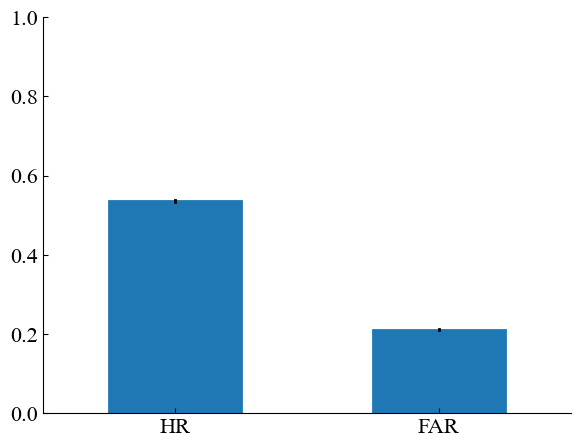

In [38]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

sns.barplot(
    data=df_hrfar_plot,
    x="type",
    y="yes_rate",
    width=0.5,
    errorbar="se",
    ax=ax,
    err_kws={"lw": 2, "color": "black"},
    facecolor="C0",
    edgecolor="C0",
    lw=2,
)

ax.set_xticks(ticks=[0, 1], labels=["HR", "FAR"])
ax.set_yticks(ticks=np.arange(0, 1.1, 0.2))
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 1)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

ax.spines[["right", "top"]].set_visible(False)
ax.set(xlabel=None, ylabel=None)

if SAVEFIG:
    plt.tick_params(labelleft=False, labelbottom=False)
    plt.savefig(f"simu2b_fig/simu2b_hrfar.pdf")
plt.show()

### Far with Lag

In [39]:
df_lure = df_simu.query("type == 'rearranged'").copy()
df_farlag = df_lure.groupby(["session", "lag"]).correct.mean().to_frame(name="yes_rate").reset_index()
df_farlag["far"] = 1 - df_farlag["yes_rate"]
df_farlag

,session,lag,yes_rate,far
0,0,1,0.833333,0.166667
1,0,2,0.833333,0.166667
2,0,3,0.770833,0.229167
3,0,4,0.708333,0.291667
4,0,5,0.875000,0.125000
...,...,...,...,...
550,110,1,0.833333,0.166667
551,110,2,0.708333,0.291667
552,110,3,0.750000,0.250000
553,110,4,0.729167,0.270833


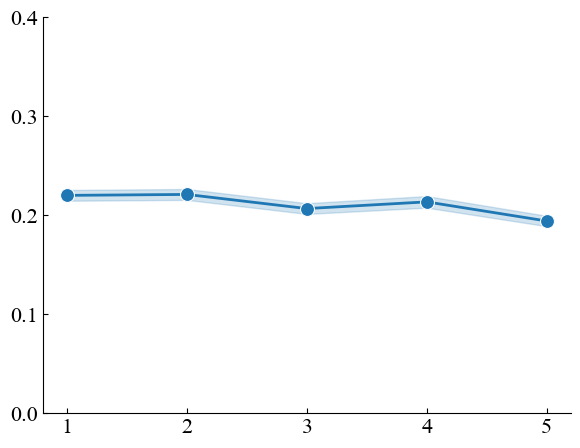

In [40]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

sns.lineplot(
    data=df_farlag,
    x="lag",
    y="far",
    marker="o",
    markersize=10,
    errorbar="se",
    err_style="band",
    ax=ax,
    linewidth=2,
    linestyle="-",
)

ax.set_xticks(ticks=np.arange(1, 6))
ax.set_yticks(ticks=np.arange(0, 0.41, 0.1))
ax.set_xlim(0.8, 5.2)
ax.set_ylim(0, 0.4)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

ax.spines[["right", "top"]].set_visible(False)
ax.set(xlabel=None, ylabel=None)

if SAVEFIG:
    plt.tick_params(labelleft=False)
    plt.savefig(f"simu2b_fig/simu2b_lag.pdf")
plt.show()

In [41]:
df_farlag_csim = df_lure.groupby(["session", "lag"]).csim.mean().to_frame(name="csim").reset_index()
df_farlag_csim

,session,lag,csim
0,0,1,0.028149
1,0,2,0.029697
2,0,3,0.027556
3,0,4,0.029079
4,0,5,0.026861
...,...,...,...
550,110,1,0.024816
551,110,2,0.029642
552,110,3,0.025807
553,110,4,0.025504


In [42]:
sessions = df_farlag_csim.session.unique()
corrs = []
for sess in sessions:
    df_sess = df_farlag_csim.query("session == @sess")
    lag = df_sess["lag"].to_numpy()
    csim = df_sess["csim"].to_numpy()
    # do correlation
    corr = sp.stats.pearsonr(lag, csim)
    corrs.append(corr)
np.mean(corrs), np.std(corrs)

(0.18810829677608026, 0.5121481923950858)

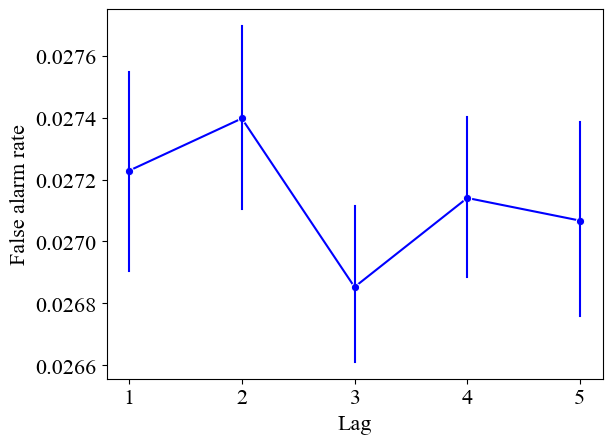

In [43]:
sns.lineplot(
    data=df_farlag_csim,
    x="lag",
    y="csim",
    color="blue",
    marker="o",
    err_style="bars",
)
# plt.ylim(0, 0.1)
plt.xlim(0.8, 5.2)
plt.xticks(np.arange(1, 6))
# plt.yticks(np.arange(0, 0.11, 0.01))
plt.xlabel("Lag")
plt.ylabel("False alarm rate")
plt.show()

### Error Check

In [44]:
# load ground truth
with open("simu2b_data/simu2b_gt.pkl", "rb") as f:
    hr_gt = pickle.load(f)
    hr_std_gt = pickle.load(f)
    far_gt = pickle.load(f)
    far_std_gt = pickle.load(f)
hr_gt, hr_std_gt, far_gt, far_std_gt

(0.5366186381796584,
 0.1633487638481977,
 array([0.21428165, 0.2174274 , 0.21721617, 0.21166567, 0.20021831]),
 array([0.14578635, 0.15351747, 0.16036269, 0.14002328, 0.13892722]))

In [45]:
hr = df_hrfar_plot.query("type == 'hr'").yes_rate.mean()
far = df_farlag.groupby("lag").far.mean().to_numpy()
hr, far

(0.5364489489489489,
 array([0.21996997, 0.22090841, 0.20664414, 0.2134009 , 0.19406907]))

In [46]:
# calculate error
err = 5 * get_wmse(hr_gt, hr, hr_std_gt) + get_wmse(far_gt, far, far_std_gt)
err

0.00850089522489226

0.00850089522489226

### Slope Check

In [47]:
import statsmodels.formula.api as smf
from scipy import stats

In [48]:
df_farlag

,session,lag,yes_rate,far
0,0,1,0.833333,0.166667
1,0,2,0.833333,0.166667
2,0,3,0.770833,0.229167
3,0,4,0.708333,0.291667
4,0,5,0.875000,0.125000
...,...,...,...,...
550,110,1,0.833333,0.166667
551,110,2,0.708333,0.291667
552,110,3,0.750000,0.250000
553,110,4,0.729167,0.270833


In [49]:
sessions = df_farlag.session.unique()
slopes = []
for sess in sessions:
    df_tmp = df_farlag.query("session == @sess").copy()
    res = smf.ols(formula="far ~ lag", data=df_tmp).fit()
    slopes.append(res.params["lag"])

In [50]:
np.mean(slopes), np.std(slopes), stats.sem(slopes)

(-0.005930930930930936, 0.01827839117149133, 0.00174277621736139)

In [51]:
# t test
t_stat, p_val = stats.ttest_1samp(slopes, 0)
t_stat, p_val

(-3.403151174458029, 0.0009300372668708093)